# Yahoo Finance v8 API — Fetch Test

Testing direct API access to `query1.finance.yahoo.com` which returned HTTP 200 (unlike `yfinance` which hits `query2` and gets rate-limited).

## 1. Imports

In [3]:

import time
import pandas as pd
import matplotlib.pyplot as plt
from curl_cffi import requests  # impersonates Chrome TLS fingerprint

print("Imports OK")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Imports OK


## 2. Fetch Raw Response

Check that the API returns HTTP 200 and inspect the raw JSON structure.

In [4]:
TICKER = "AAPL"

headers = {
    'accept': '*/*',
    'origin': 'https://finance.yahoo.com',
    'referer': 'https://finance.yahoo.com/quote/AAPL/history/',
    'user-agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36',
}

url = f"https://query1.finance.yahoo.com/v8/finance/chart/{TICKER}?includeAdjustedClose=true&interval=1d&symbol={TICKER}&range=5y"

# impersonate="chrome" makes curl_cffi use Chrome's TLS fingerprint
response = requests.get(url, headers=headers, impersonate="chrome")

print(f"Status code : {response.status_code}")
print(f"Content-Type: {response.headers.get('Content-Type')}")

Status code : 200
Content-Type: application/json;charset=utf-8


In [5]:
# Inspect top-level keys in the JSON response
payload = response.json()
print("Top-level keys:", list(payload.keys()))
print("Chart keys    :", list(payload["chart"].keys()))

result = payload["chart"]["result"]
if result:
    print("Result[0] keys:", list(result[0].keys()))
else:
    print("ERROR:", payload["chart"]["error"])

Top-level keys: ['chart']
Chart keys    : ['result', 'error']
Result[0] keys: ['meta', 'timestamp', 'indicators']


## 3. Parse into DataFrame

In [6]:
chart   = result[0]
quotes  = chart["indicators"]["quote"][0]
adjclose_data = chart["indicators"].get("adjclose", [{}])[0].get("adjclose", quotes["close"])

df = pd.DataFrame({
    "Open":   quotes["open"],
    "High":   quotes["high"],
    "Low":    quotes["low"],
    "Close":  adjclose_data,   # adjusted close (splits + dividends)
    "Volume": quotes["volume"],
}, index=pd.to_datetime(chart["timestamp"], unit="s", utc=True)
              .tz_convert("America/New_York")
              .normalize())

df.index.name = "Date"
df = df.astype(float).dropna().sort_index()

print(f"Rows     : {len(df)}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
df.tail()

Rows     : 1255
Date range: 2021-04-08 → 2026-04-07


,Open,High,Low,Close,Volume
Date,,,,,
2026-03-31 00:00:00-04:00,247.910004,255.479996,247.100006,253.789993,49598100.0
2026-04-01 00:00:00-04:00,254.080002,256.179993,253.330002,255.630005,40059400.0
2026-04-02 00:00:00-04:00,254.199997,256.130005,250.649994,255.919998,31289400.0
2026-04-06 00:00:00-04:00,256.510010,262.160004,256.459991,258.859985,29329900.0
2026-04-07 00:00:00-04:00,256.160004,256.200012,245.699997,253.500000,61377300.0


## 4. Quick Plot — Close Price

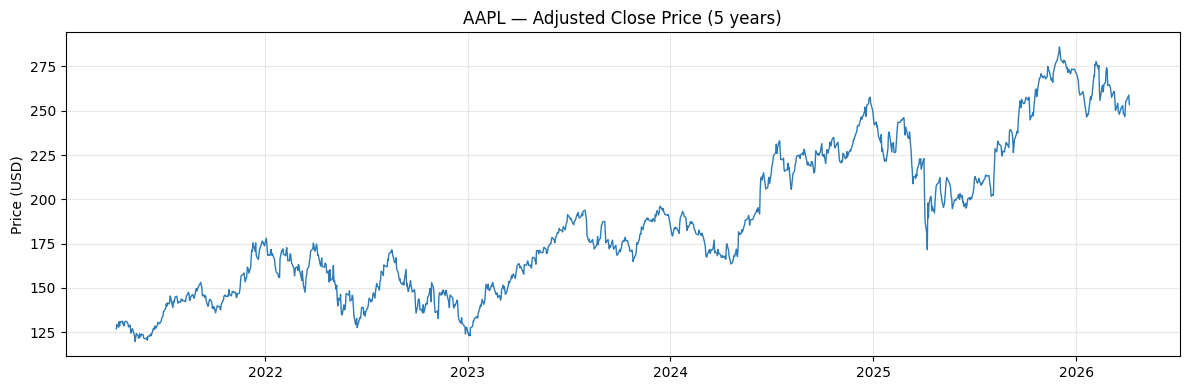

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["Close"], linewidth=1, color="#2c7bb6")
ax.set_title(f"{TICKER} — Adjusted Close Price (5 years)")
ax.set_ylabel("Price (USD)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Test Multiple Tickers

If this works, the approach is ready to be wired into `src/data/loader.py`.

In [8]:
def fetch_ohlcv(ticker: str, range: str = "5y") -> pd.DataFrame:
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}?includeAdjustedClose=true&interval=1d&symbol={ticker}&range={range}"
    resp = requests.get(url, headers=headers, impersonate="chrome")

    if resp.status_code != 200:
        print(f"{ticker}: HTTP {resp.status_code}")
        return None

    chart = resp.json()["chart"]["result"][0]
    quotes = chart["indicators"]["quote"][0]
    adjclose = chart["indicators"].get("adjclose", [{}])[0].get("adjclose", quotes["close"])

    df = pd.DataFrame({
        "Open":   quotes["open"],
        "High":   quotes["high"],
        "Low":    quotes["low"],
        "Close":  adjclose,
        "Volume": quotes["volume"],
    }, index=pd.to_datetime(chart["timestamp"], unit="s", utc=True)
                  .tz_convert("America/New_York").normalize())
    df.index.name = "Date"
    return df.astype(float).dropna().sort_index()


for t in ["AAPL", "MSFT", "GOOG"]:
    result_df = fetch_ohlcv(t)
    if result_df is not None:
        print(f"{t}: {len(result_df)} rows, {result_df.index.min().date()} → {result_df.index.max().date()}")
    time.sleep(0.5)

AAPL: 1255 rows, 2021-04-08 → 2026-04-07
MSFT: 1255 rows, 2021-04-08 → 2026-04-07
GOOG: 1255 rows, 2021-04-08 → 2026-04-07
